In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
import sys
import pickle
import json

sys.path.insert(0, "../../../utils")

from modules import *

import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

REGION = 'Nord'

In [2]:
dataframe = pd.read_csv(f'../../../data/{REGION}/CM_{REGION}_Test_Dataset_2015-2025.csv', encoding=enc)

In [3]:
dataframe

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015-01,2015,1,0.500,...,33.33,26.33,1968.0,537.0,0.0,114.71,1294.0,1.0,240.0,1294.0
1,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015-01,2015,1,0.500,...,34.33,25.67,2013.0,583.0,0.0,120.04,1353.0,2.0,94.0,1275.0
2,nord,benoue,bibemi,bide,13.972945,9.422292,2015-01,2015,1,0.500,...,34.50,26.83,1845.0,540.0,0.0,120.79,1240.0,0.0,81.0,1178.0
3,nord,benoue,bibemi,dengui,13.642496,9.235656,2015-01,2015,1,0.500,...,33.67,25.83,2049.0,539.0,0.0,112.59,1314.0,1.0,243.0,1314.0
4,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015-01,2015,1,0.500,...,34.00,28.00,1872.0,521.0,0.0,119.39,1228.0,0.0,98.0,997.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18495,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2025-08,2025,8,-0.866,...,29.83,22.83,2887.0,796.0,0.0,111.36,1749.0,0.0,288.0,1749.0
18496,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2025-08,2025,8,-0.866,...,31.17,23.67,2647.0,795.0,0.0,118.21,1678.0,0.0,114.0,1678.0
18497,nord,mayo-rey,touboro,touboro,15.293957,7.759324,2025-08,2025,8,-0.866,...,32.17,23.83,2850.0,833.0,0.0,116.11,1796.0,0.0,249.0,1780.0
18498,nord,mayo-rey,touboro,vogzom,14.714359,7.747549,2025-08,2025,8,-0.866,...,31.00,23.00,2877.0,766.0,0.0,109.01,1708.0,0.0,305.0,432.0


In [4]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [5]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [6]:
inference = dataframe[dataframe["dt_prediction"] > pd.Period("2024-01", freq="M")]
inference.reset_index(drop=True, inplace=True)

inference.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2024-02,0.866,0.5,0.144959,-0.160504,-0.238388,0.160504,...,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2024-02,0.866,0.5,0.153655,-0.158118,-0.236255,0.158118,...,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2024-02,0.866,0.5,0.153234,-0.146727,-0.254375,0.146727,...,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2024-02,0.866,0.5,0.176150,-0.136317,-0.242030,0.136317,...,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2024-02,0.866,0.5,0.155640,-0.079037,-0.249233,0.079037,...,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [14]:
with open('saved/CM_{REGION}_bin_ranges.pkl', 'rb') as f:
    bin_ranges = pickle.load(f)

num_of_classes = len(bin_ranges) - 1
print(f'Number of classes: {num_of_classes}')

Number of classes: 8


In [15]:
with open(f"saved/CM_{REGION}_rfecv_model.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

with open(f"saved/CM_{REGION}_scaler.pkl", "rb") as f:
    fitted_scaler = pickle.load(f)

with open(f"saved/CM_{REGION}_imputer.pkl", "rb") as f:
    fitted_imputer = pickle.load(f)

with open(f"saved/CM_{REGION}_xgb_model.pkl", "rb") as f:
    fitted_model = pickle.load(f)

In [17]:
X_test = inference.select_dtypes(exclude=['object', 'period[M]'])
X_test.head()

,x,y,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,13.770202,9.240232,0.866,0.5,0.144959,-0.160504,-0.238388,0.160504,0.148059,-0.167132,...,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,13.949181,9.263633,0.866,0.5,0.153655,-0.158118,-0.236255,0.158118,0.148100,-0.162418,...,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,13.972945,9.422292,0.866,0.5,0.153234,-0.146727,-0.254375,0.146727,0.154945,-0.134596,...,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,13.642496,9.235656,0.866,0.5,0.176150,-0.136317,-0.242030,0.136317,0.167262,-0.142923,...,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,13.994667,9.585190,0.866,0.5,0.155640,-0.079037,-0.249233,0.079037,0.155329,-0.070737,...,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [18]:
X_test_scaled = pd.DataFrame(fitted_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [19]:
X_test_imputed = pd.DataFrame(fitted_imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [20]:
X_test_imputed = pd.DataFrame(fitted_scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

In [21]:
X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X_test.columns[fitted_rfe.support_], index=X_test.index)

In [22]:
y_test_pred = fitted_model.predict(X_test_rfe)

In [23]:
y_test_pred = np.clip(np.round(y_test_pred), 0, num_of_classes -1).astype(int)

In [24]:
y_test_pred

array([2, 4, 2, ..., 6, 5, 5])

In [25]:
results_test = pd.DataFrame({'prediction': y_test_pred})

results_test['dt_prediction'] = inference.loc[results_test.index, 'dt_prediction']
results_test['dt_reference'] = results_test['dt_prediction']+3

results_test.reset_index(drop=True, inplace=True)

In [26]:
results_test

,prediction,dt_prediction,dt_reference
0,2,2024-02,2024-05
1,4,2024-02,2024-05
2,2,2024-02,2024-05
3,3,2024-02,2024-05
4,2,2024-02,2024-05
...,...,...,...
2750,5,2025-08,2025-11
2751,6,2025-08,2025-11
2752,6,2025-08,2025-11
2753,5,2025-08,2025-11


In [27]:
results_df = pd.merge(inference[['location', 'x', 'y']], results_test, left_index=True, right_index=True, how='inner')

In [28]:
results_df

,location,x,y,prediction,dt_prediction,dt_reference
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2,2024-02,2024-05
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,4,2024-02,2024-05
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2,2024-02,2024-05
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,3,2024-02,2024-05
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2,2024-02,2024-05
...,...,...,...,...,...,...
2750,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,5,2025-08,2025-11
2751,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,6,2025-08,2025-11
2752,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,6,2025-08,2025-11
2753,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,5,2025-08,2025-11


<Axes: title={'center': 'Predicted Case Bin Distribution'}, xlabel='Bins', ylabel='Frequency'>

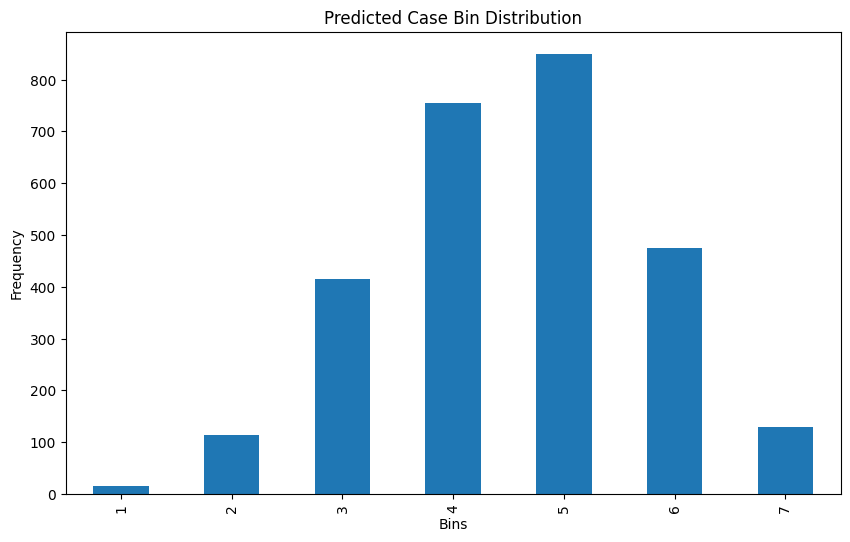

In [29]:
results_df.prediction.value_counts().sort_index().plot(kind='bar', 
                                                              figsize=(10, 6), 
                                                              title='Predicted Case Bin Distribution', 
                                                              xlabel='Bins', 
                                                              ylabel='Frequency')